# Volume experiment — new three-polytope format

For each quantization bit-width $b$, we have three nested polytopes per sample:
- $A_{\text{base}}$: model activation + model classification (model-only)
- $A_{\text{correct}}^b$: $A_{\text{base}}$ + qmodel activation
- $A_{\text{both}}^b$: $A_{\text{correct}}^b$ + qmodel classification

Containment: $A_{\text{base}} \supseteq A_{\text{correct}}^b \supseteq A_{\text{both}}^b$

This notebook plots two **generalized accuracy** curves (values in $[0, 1]$, closer to 1 = better quantization):
1. **Curve 1**: $\dfrac{\sum_i d\!\left(\Xi^b_{\boldsymbol{x}_i}\right)}{\sum_i d\!\left(\Xi^b_{S(\boldsymbol{x}_i)}\right)}$ — fraction of the base region preserved when requiring both models to agree (measures total quantization impact)
2. **Curve 2**: $\dfrac{\sum_i d\!\left(\Xi^b_{\boldsymbol{x}_i}\right)}{\sum_i d\!\left(\Xi^b_{S(\boldsymbol{x}_i) \wedge \tilde{S}(\boldsymbol{x}_i)}\right)}$ — fraction of the activation-constrained region preserved when adding qmodel classification constraints (measures classification alignment)
3. **Histogram**: number of zero `widths_both[b]` entries per bit-width (empty polytopes = qmodel misclassifies $x_0$)

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Configuration

In [ ]:
# ------------------------------------------------------------------ #
# Global config — change MODEL_TYPE to switch between MLP and CNN    #
# ------------------------------------------------------------------ #

MODE             = "aug"   # ""  → original data
                           # "aug" → augmented data
MODEL_TYPE       = "mlp"   # "mlp" or "cnn"
COMBINE_ORIGINAL = True   # True: load original + augmented (only when MODE="aug")
SAVE_PDF         = True   # save plots as PDF in the results directory

RESULTS_ROOT = ROOT / "results"
# Build results dir name: volumes_mlp, volumes_mlp_aug, etc.
_suffix     = f"_{MODE}" if MODE else ""
RESULTS_DIR = RESULTS_ROOT / f"volumes_{MODEL_TYPE}{_suffix}"
_combine_suffix = "_combined" if (MODE == "aug" and COMBINE_ORIGINAL) else ""
_plot_tag       = f"{MODEL_TYPE}{_suffix}{_combine_suffix}"  # e.g. "mlp", "mlp_aug", "mlp_aug_combined"
print(f"Plot tag         : {_plot_tag}")
print(f"Model type       : {MODEL_TYPE}")
print(f"Mode             : {MODE if MODE else 'original'}")
print(f"Combine original : {COMBINE_ORIGINAL}")
print(f"Results dir      : {RESULTS_DIR}")
print(f"Save PDF         : {SAVE_PDF}")

Plot tag         : mlp
Model type       : mlp
Mode             : original
Combine original : True
Results dir      : /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/volumes_mlp
Save PDF         : True


## Load results

In [3]:
def load_records(results_dir):
    recs = []
    for f in sorted(Path(results_dir).glob("volumes_sample*.json")):
        with open(f) as fh:
            recs.append(json.load(fh))
    return recs

records = load_records(RESULTS_DIR)

if MODE == "aug" and COMBINE_ORIGINAL:
    orig_dir  = RESULTS_ROOT / f"volumes_{MODEL_TYPE}"
    orig_recs = load_records(orig_dir)
    records   = orig_recs + records
    print(f"Combined: {len(orig_recs)} original + {len(records)-len(orig_recs)} augmented = {len(records)} total")
else:
    print(f"Found {len(records)} result files.")

bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

Found 1999 result files.
Bits grid: [4, 6, 8, 10, 12, 16]


## Compute sums and track zero / NaN entries

- `width_base` and `widths_correct` should never be 0 or NaN (A_base and A_correct always contain $x_0$).
- `widths_both[b]` can be 0 when the qmodel misclassifies $x_0$ (empty polytope).

In [4]:
def is_bad(v):
    """True if value is 0, NaN, or None."""
    return v is None or math.isnan(v) or v == 0.0

# ---------------------------------------------------------------------------
# Per-sample accumulators (for mean-of-ratios — the correct GACC definition)
# ---------------------------------------------------------------------------
ratios_1 = {b: [] for b in bits_grid}   # per-sample V3/V1
ratios_2 = {b: [] for b in bits_grid}   # per-sample V3/V2

# Legacy sums (ratio-of-sums — kept for comparison)
sum_base    = 0.0
sum_correct = {b: 0.0 for b in bits_grid}
sum_both    = {b: 0.0 for b in bits_grid}
zero_both   = {b: [] for b in bits_grid}

for r in records:
    idx = r["sample_idx"]
    wb  = r["width_base"]
    wb_val = 0.0 if is_bad(wb) else wb
    sum_base += wb_val

    for b in bits_grid:
        wc  = r["widths_correct"][str(b)]
        wbo = r["widths_both"][str(b)]

        wc_val  = 0.0 if is_bad(wc)  else wc
        wbo_val = 0.0 if is_bad(wbo) else wbo

        sum_correct[b] += wc_val
        if is_bad(wbo):
            zero_both[b].append(idx)
        sum_both[b] += wbo_val

        # mean-of-ratios: 0/anything → 0; anything/0 → 0 (degenerate sample)
        ratios_1[b].append(wbo_val / wb_val  if wb_val  > 0 else 0.0)
        ratios_2[b].append(wbo_val / wc_val  if wc_val  > 0 else 0.0)

# ---------------------------------------------------------------------------
# GACC — two flavours
# ---------------------------------------------------------------------------
# Preferred: mean of per-sample ratios (each sample contributes equally)
gacc1_mean = np.array([np.mean(ratios_1[b]) for b in bits_grid])
gacc2_mean = np.array([np.mean(ratios_2[b]) for b in bits_grid])

# Legacy: ratio of sums (large-volume samples dominate)
gacc1_sum  = np.array([sum_both[b] / sum_base         if sum_base        > 0 else np.nan for b in bits_grid])
gacc2_sum  = np.array([sum_both[b] / sum_correct[b]   if sum_correct[b]  > 0 else np.nan for b in bits_grid])

n_zeros = [len(zero_both[b]) for b in bits_grid]

# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print(f"Samples  : {len(records)}")
print(f"sum_base : {sum_base:.4f}")
print()
print(f"{'bits':>6}  {'gacc1_mean':>12}  {'gacc1_sum':>12}  {'gacc2_mean':>12}  {'gacc2_sum':>12}  {'n_zeros':>8}")
for i, b in enumerate(bits_grid):
    print(f"  {b:4d}  {gacc1_mean[i]:12.6f}  {gacc1_sum[i]:12.6f}  "
          f"{gacc2_mean[i]:12.6f}  {gacc2_sum[i]:12.6f}  {n_zeros[i]:8d}")


Samples  : 1999
sum_base : 79580.0623

  bits    gacc1_mean     gacc1_sum    gacc2_mean     gacc2_sum   n_zeros
     4      0.940333      0.940467      0.994483      0.999486        10
     6      0.985891      0.985929      0.999998      0.999998         0
     8      0.996406      0.996416      1.000000      1.000000         0
    10      0.999066      0.999068      1.000000      1.000000         0
    12      0.999779      0.999780      1.000000      1.000000         0
    16      0.999985      0.999985      1.000000      1.000000         0


## Plots

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_gacc1_mlp.pdf


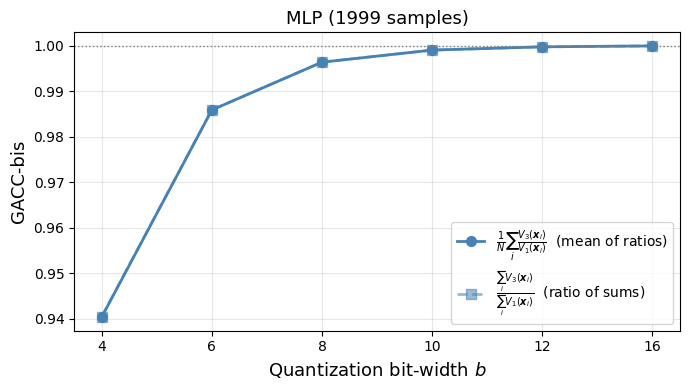

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_gacc2_mlp.pdf


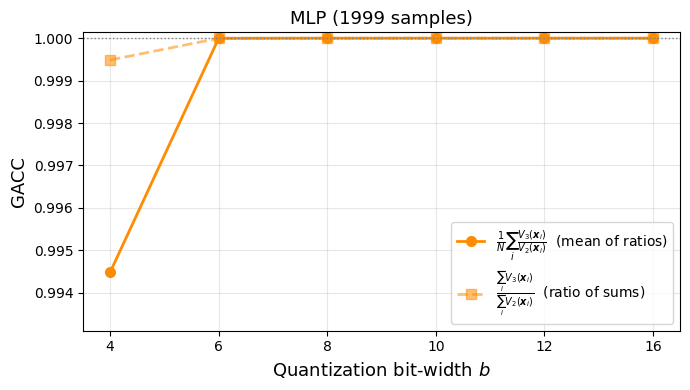

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_empty_both_polytopes_mlp.pdf


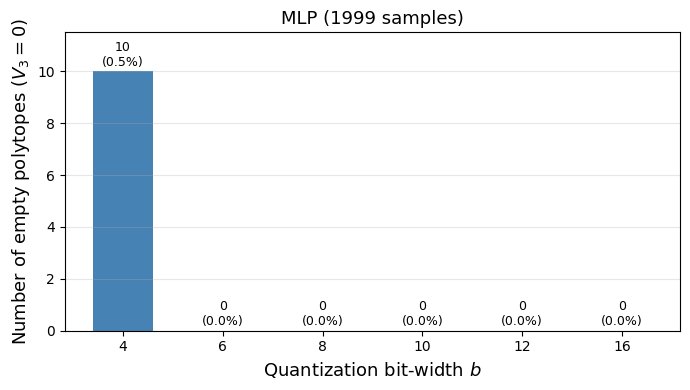

In [5]:
bits_arr = np.array(bits_grid)
x_ticks  = range(len(bits_grid))

# ------------------------------------------------------------------ #
# Figure 1: GACC_1 = V3/V1 — mean-of-ratios vs ratio-of-sums        #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_ticks, gacc1_mean, marker="o", linewidth=2, markersize=7,
        color="steelblue",
        label=r"$\frac{1}{N}\sum_i \frac{V_3(\boldsymbol{x}_i)}{V_1(\boldsymbol{x}_i)}$  (mean of ratios)")
ax.plot(x_ticks, gacc1_sum,  marker="s", linewidth=2, markersize=7,
        color="steelblue", linestyle="--", alpha=0.55,
        label=r"$\frac{\sum_i V_3(\boldsymbol{x}_i)}{\sum_i V_1(\boldsymbol{x}_i)}$  (ratio of sums)")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("GACC-bis", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_gacc1_{_plot_tag}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

# ------------------------------------------------------------------ #
# Figure 2: GACC_2 = V3/V2 — mean-of-ratios vs ratio-of-sums        #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_ticks, gacc2_mean, marker="o", linewidth=2, markersize=7,
        color="darkorange",
        label=r"$\frac{1}{N}\sum_i \frac{V_3(\boldsymbol{x}_i)}{V_2(\boldsymbol{x}_i)}$  (mean of ratios)")
ax.plot(x_ticks, gacc2_sum,  marker="s", linewidth=2, markersize=7,
        color="darkorange", linestyle="--", alpha=0.55,
        label=r"$\frac{\sum_i V_3(\boldsymbol{x}_i)}{\sum_i V_2(\boldsymbol{x}_i)}$  (ratio of sums)")
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)

# Zoom around the interesting range
all_vals = np.concatenate([gacc2_mean, gacc2_sum])
valid    = all_vals[~np.isnan(all_vals)]
margin   = max((1.0 - valid.min()) * 0.25, 1e-6)
ax.set_ylim(valid.min() - margin, 1.0 + margin * 0.1)

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("GACC", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_gacc2_{_plot_tag}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

# ------------------------------------------------------------------ #
# Figure 3: zero / NaN histogram                                     #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(x_ticks, n_zeros, color="steelblue", width=0.6)
ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Number of empty polytopes ($V_3=0$)", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x_ticks)
ax.set_xticklabels(bits_arr)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(n_zeros) + 1.5)

for i, (b, n) in enumerate(zip(bits_grid, n_zeros)):
    pct = 100 * n / len(records)
    ax.text(i, n + 0.1, f"{n}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_empty_both_polytopes_{_plot_tag}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()


## Mean and std of widths per bit-width

width_base    : mean=39.8099  std=0.5713

  bits    mean_correct   std_correct     mean_both    std_both
     4         37.4592        2.7956       36.4399      2.8517
     6         39.2498        0.6767       38.2498      0.6768
     8         39.6673        0.5986       38.6672      0.5986
    10         39.7728        0.5787       38.7728      0.5787
    12         39.8012        0.5730       38.8012      0.5730
    16         39.8094        0.5714       38.8094      0.5714
Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_mean_std_widths_mlp.pdf


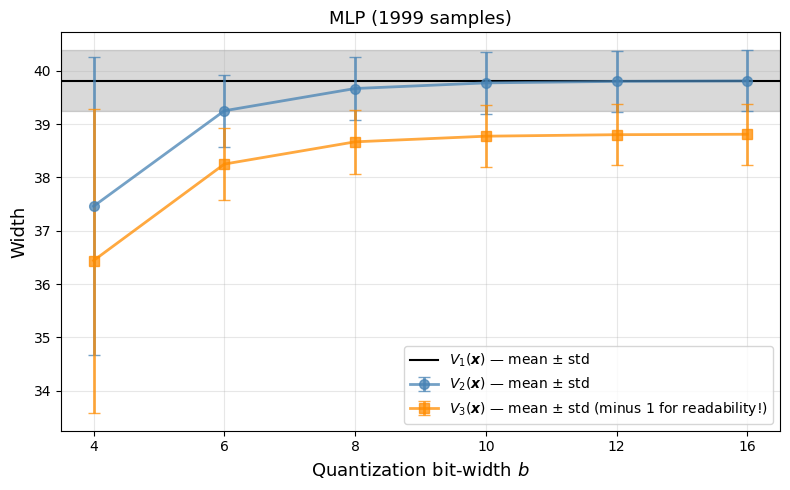

In [6]:
import numpy as np

# Collect per-sample arrays
arr_base    = np.array([r["width_base"] for r in records])
arr_correct = {b: np.array([r["widths_correct"][str(b)] for r in records]) for b in bits_grid}
arr_both    = {b: np.array([r["widths_both"][str(b)]    for r in records]) for b in bits_grid}

# Means and stds
mean_base = arr_base.mean();  std_base = arr_base.std()

mean_correct = np.array([arr_correct[b].mean() for b in bits_grid])
std_correct  = np.array([arr_correct[b].std()  for b in bits_grid])

mean_both    = np.array([arr_both[b].mean() for b in bits_grid]) - 1 # minus 1 for readability)
std_both     = np.array([arr_both[b].std()  for b in bits_grid])

print(f"width_base    : mean={mean_base:.4f}  std={std_base:.4f}")
print()
print(f"{'bits':>6}  {'mean_correct':>14}  {'std_correct':>12}  {'mean_both':>12}  {'std_both':>10}")
for i, b in enumerate(bits_grid):
    print(f"  {b:4d}  {mean_correct[i]:14.4f}  {std_correct[i]:12.4f}  {mean_both[i]:12.4f}  {std_both[i]:10.4f}")

# ------------------------------------------------------------------ #
# Plot: mean ± std of width_base, widths_correct, widths_both        #
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(bits_grid))

# width_base: constant across b — draw as horizontal band
ax.axhline(mean_base, color="black", linewidth=1.5, linestyle="-",  label=r"$V_1(\boldsymbol{x})$ — mean ± std")
ax.axhspan(mean_base - std_base, mean_base + std_base, alpha=0.15, color="black")

# widths_correct
ax.errorbar(x, mean_correct, yerr=std_correct, marker="o", linewidth=2, markersize=7,
            capsize=4, color="steelblue", alpha=0.75,
            label=r"$V_2(\boldsymbol{x})$ — mean ± std")

# widths_both
ax.errorbar(x, mean_both, yerr=std_both, marker="s", linewidth=2, markersize=7,
            capsize=4, color="darkorange", alpha=0.75,
            label=r"$V_3(\boldsymbol{x})$ — mean ± std (minus 1 for readability!)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel("Width", fontsize=13)
ax.set_title(f"{MODEL_TYPE.upper()} ({len(records)} samples)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(bits_grid)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_mean_std_widths_{_plot_tag}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()

## Inspect zero / NaN samples per bit-width

In [7]:
for b in bits_grid:
    idxs = zero_both[b]
    print(f"bits={b:2d}  n_zeros={len(idxs):4d}  sample_indices={idxs[:20]}{'...' if len(idxs) > 20 else ''}")

bits= 4  n_zeros=  10  sample_indices=[110, 1203, 1707, 1755, 1931, 497, 651, 777, 851, 926]
bits= 6  n_zeros=   0  sample_indices=[]
bits= 8  n_zeros=   0  sample_indices=[]
bits=10  n_zeros=   0  sample_indices=[]
bits=12  n_zeros=   0  sample_indices=[]
bits=16  n_zeros=   0  sample_indices=[]


## Visual comparison: original vs augmented samples

Saved to /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes/results/plot_original_and_augmented_mlp.pdf


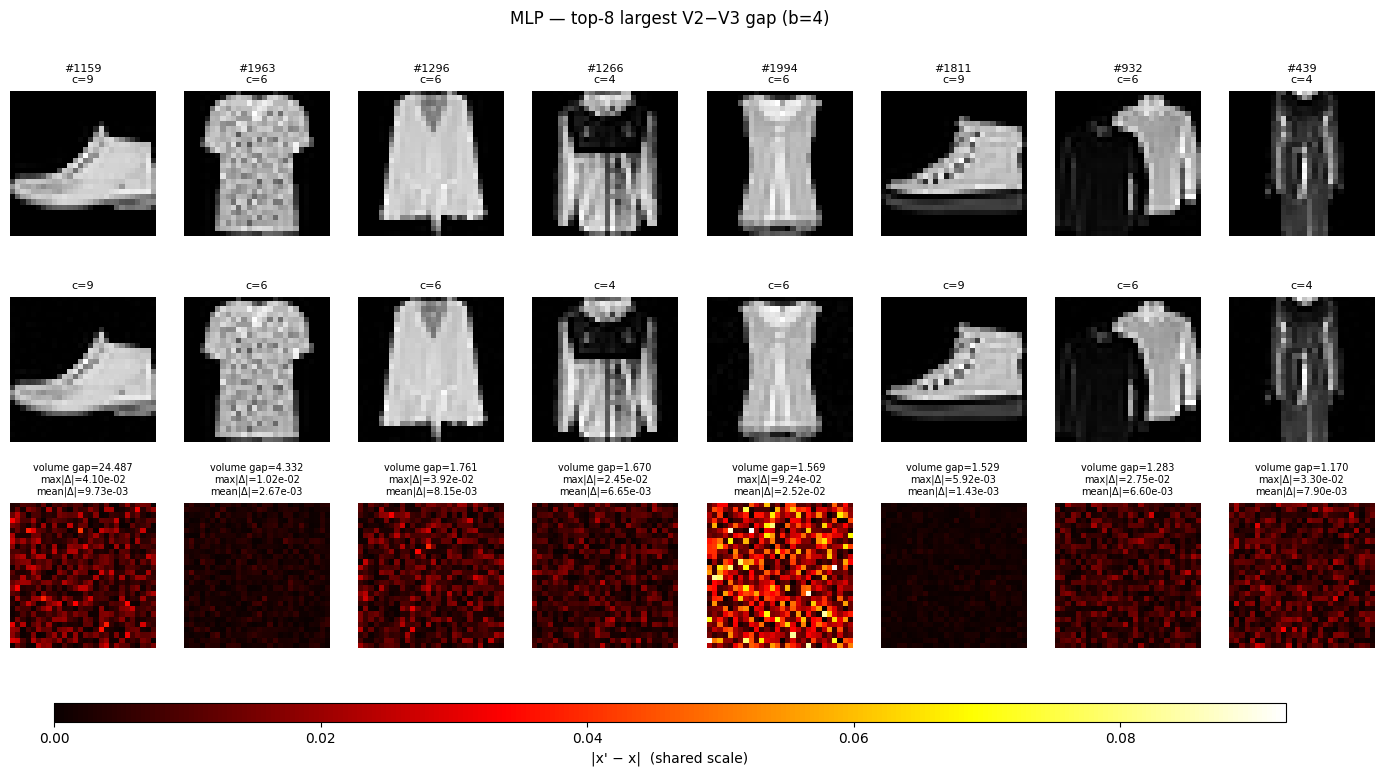

  sample_idx   gap (V2-V3)    max|Δ|   mean|Δ|
        1159       24.4868    0.0410    0.0097
        1963        4.3315    0.0102    0.0027
        1296        1.7612    0.0392    0.0081
        1266        1.6697    0.0245    0.0066
        1994        1.5692    0.0924    0.0252
        1811        1.5288    0.0059    0.0014
         932        1.2827    0.0275    0.0066
         439        1.1697    0.0330    0.0079


In [8]:
# ------------------------------------------------------------------ #
# PLOT_MODE = "interesting"  → show the N_SHOW samples where
#                              (widths_correct[b] - widths_both[b])
#                              is largest at BITS_INTEREST bit-width.
# PLOT_MODE = "random"       → show N_SHOW randomly chosen samples.
# ------------------------------------------------------------------ #
import torch, json, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOT_MODE      = "interesting"   # "interesting" or "random"
BITS_INTEREST  = 4               # bit-width used to rank samples
N_SHOW         = 8
AUG_SEED       = 42
SEED_VIZ       = 0

# --- Compute per-sample gap = widths_correct[b] - widths_both[b] ---
gaps = []
for r in records:
    wc  = r["widths_correct"][str(BITS_INTEREST)]
    wbo = r["widths_both"][str(BITS_INTEREST)]
    wc  = 0.0 if (wc  is None or math.isnan(wc))  else wc
    wbo = 0.0 if (wbo is None or math.isnan(wbo)) else wbo
    gaps.append((wc - wbo, r["sample_idx"]))

gaps_sorted = sorted(gaps, reverse=True)

if PLOT_MODE == "interesting":
    selected = [idx for _, idx in gaps_sorted[:N_SHOW]]
    title_suffix = f"top-{N_SHOW} largest V2−V3 gap (b={BITS_INTEREST})"
else:
    rng_viz = np.random.default_rng(SEED_VIZ)
    all_idx = [r["sample_idx"] for r in records]
    selected = list(rng_viz.choice(all_idx, size=N_SHOW, replace=False))
    title_suffix = f"random (seed={SEED_VIZ})"

# --- Load datasets ---
data_orig = torch.load(ROOT / "data" / f"fashionMNIST_correct_{MODEL_TYPE}.pt",  weights_only=False)
data_aug  = torch.load(ROOT / "data" / f"fashionMNIST_augmented_{MODEL_TYPE}_seed{AUG_SEED}.pt", weights_only=False)

def to_img(x):
    arr = x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.array(x)
    return arr.reshape(28, 28)

orig_imgs, aug_imgs, diff_imgs, gap_vals = [], [], [], []
for idx in selected:
    x_o, _ = data_orig[idx]
    x_a, _ = data_aug[idx]
    io = to_img(x_o); ia = to_img(x_a)
    orig_imgs.append(io); aug_imgs.append(ia)
    diff_imgs.append(np.abs(ia - io))
    gap_vals.append(next(g for g, i in gaps if i == idx))

shared_vmax = max(d.max() for d in diff_imgs)
shared_vmax = shared_vmax if shared_vmax > 0 else 1.0

fig, axes = plt.subplots(3, N_SHOW, figsize=(2.2 * N_SHOW, 7.5))
fig.subplots_adjust(bottom=0.12, hspace=0.3)

for col, idx in enumerate(selected):
    io = orig_imgs[col]; ia = aug_imgs[col]; idiff = diff_imgs[col]

    axes[0, col].imshow(io, cmap="gray", vmin=io.min(), vmax=io.max())
    axes[0, col].set_title(f"#{idx}\nc={int(data_orig[idx][1])}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(ia, cmap="gray", vmin=io.min(), vmax=io.max())
    axes[1, col].set_title(f"c={int(data_aug[idx][1])}", fontsize=8)
    axes[1, col].axis("off")

    im = axes[2, col].imshow(idiff, cmap="hot", vmin=0, vmax=shared_vmax)
    axes[2, col].axis("off")
    axes[2, col].set_title(
    f"volume gap={gap_vals[col]:.3f}\n"
    f"max|Δ|={idiff.max():.2e}\n"
    f"mean|Δ|={idiff.mean():.2e}",
    fontsize=7
)

axes[0, 0].set_ylabel("Original",     fontsize=10, rotation=0, labelpad=55)
axes[1, 0].set_ylabel("Augmented",    fontsize=10, rotation=0, labelpad=55)
axes[2, 0].set_ylabel("|Difference|", fontsize=10, rotation=0, labelpad=55)

cbar_ax = fig.add_axes([0.15, 0.03, 0.70, 0.025])
fig.colorbar(im, cax=cbar_ax, orientation="horizontal", label="|x' − x|  (shared scale)")

fig.suptitle(
    f"{MODEL_TYPE.upper()} — {title_suffix}",
    fontsize=12
)

if SAVE_PDF:
    path = RESULTS_ROOT / f"plot_original_and_augmented_{MODEL_TYPE}{MODE}.pdf"
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved to {path}")
plt.show()



# --- Print gap table for selected samples ---
print(f"{'sample_idx':>12}  {'gap (V2-V3)':>12}  {'max|Δ|':>8}  {'mean|Δ|':>8}")
for col, idx in enumerate(selected):
    idiff = diff_imgs[col]
    print(f"{idx:12d}  {gap_vals[col]:12.4f}  {idiff.max():8.4f}  {idiff.mean():8.4f}")
